In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_smoothing_spline


In [2]:
t_data = pd.read_csv("/content/drive/MyDrive/GLB.Ts+dSST.csv", na_values= "***", skiprows = 1)
t_data

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.18,-0.24,-0.09,-0.16,-0.10,-0.21,-0.18,-0.10,-0.15,-0.23,-0.22,-0.17,-0.17,NaN,NaN,-0.12,-0.17,-0.20
1,1881,-0.20,-0.14,0.03,0.05,0.06,-0.19,0.00,-0.04,-0.15,-0.22,-0.19,-0.07,-0.09,-0.10,-0.17,0.05,-0.07,-0.19
2,1882,0.16,0.14,0.04,-0.16,-0.14,-0.22,-0.16,-0.08,-0.15,-0.23,-0.17,-0.36,-0.11,-0.09,0.07,-0.09,-0.16,-0.18
3,1883,-0.29,-0.37,-0.12,-0.19,-0.18,-0.07,-0.07,-0.14,-0.22,-0.11,-0.24,-0.11,-0.18,-0.20,-0.34,-0.16,-0.09,-0.19
4,1884,-0.13,-0.09,-0.36,-0.40,-0.34,-0.35,-0.31,-0.28,-0.27,-0.25,-0.33,-0.31,-0.28,-0.27,-0.11,-0.37,-0.31,-0.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,2019,0.93,0.95,1.17,1.01,0.85,0.91,0.94,0.95,0.93,1.01,0.99,1.09,0.98,0.96,0.93,1.01,0.93,0.98
140,2020,1.17,1.24,1.17,1.13,1.02,0.92,0.90,0.88,0.99,0.89,1.11,0.81,1.02,1.04,1.17,1.11,0.90,0.99
141,2021,0.82,0.64,0.89,0.76,0.78,0.84,0.92,0.82,0.92,1.00,0.94,0.86,0.85,0.85,0.76,0.81,0.86,0.95
142,2022,0.91,0.89,1.05,0.84,0.84,0.92,0.93,0.95,0.90,0.97,0.73,0.80,0.89,0.90,0.89,0.91,0.94,0.86


### lowercase of column header

In [3]:
t_data.columns = t_data.columns.str.lower()
#weather.columns = weather.columns.str.lower()

In [4]:
t_data

,year,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec,j-d,d-n,djf,mam,jja,son
0,1880,-0.18,-0.24,-0.09,-0.16,-0.10,-0.21,-0.18,-0.10,-0.15,-0.23,-0.22,-0.17,-0.17,NaN,NaN,-0.12,-0.17,-0.20
1,1881,-0.20,-0.14,0.03,0.05,0.06,-0.19,0.00,-0.04,-0.15,-0.22,-0.19,-0.07,-0.09,-0.10,-0.17,0.05,-0.07,-0.19
2,1882,0.16,0.14,0.04,-0.16,-0.14,-0.22,-0.16,-0.08,-0.15,-0.23,-0.17,-0.36,-0.11,-0.09,0.07,-0.09,-0.16,-0.18
3,1883,-0.29,-0.37,-0.12,-0.19,-0.18,-0.07,-0.07,-0.14,-0.22,-0.11,-0.24,-0.11,-0.18,-0.20,-0.34,-0.16,-0.09,-0.19
4,1884,-0.13,-0.09,-0.36,-0.40,-0.34,-0.35,-0.31,-0.28,-0.27,-0.25,-0.33,-0.31,-0.28,-0.27,-0.11,-0.37,-0.31,-0.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,2019,0.93,0.95,1.17,1.01,0.85,0.91,0.94,0.95,0.93,1.01,0.99,1.09,0.98,0.96,0.93,1.01,0.93,0.98
140,2020,1.17,1.24,1.17,1.13,1.02,0.92,0.90,0.88,0.99,0.89,1.11,0.81,1.02,1.04,1.17,1.11,0.90,0.99
141,2021,0.82,0.64,0.89,0.76,0.78,0.84,0.92,0.82,0.92,1.00,0.94,0.86,0.85,0.85,0.76,0.81,0.86,0.95
142,2022,0.91,0.89,1.05,0.84,0.84,0.92,0.93,0.95,0.90,0.97,0.73,0.80,0.89,0.90,0.89,0.91,0.94,0.86


### different ways of subsetting the columns in pandas 

In [5]:
#t_data.iloc[:, 1:3]
#t_data[["Year", "Jan", "Feb"]]
#t_data[t_data.columns[0:13]]
df_temp = t_data [["year", "j-d"]]


## data for the spiral chat in year month and values

In [6]:
t_spiral = t_data[t_data.columns[0:13]]

### how to rename columns in pandas

In [7]:
df1 = df_temp.rename(columns = {"year" : "year", "j-d" : "t_diff"})
df1

,year,t_diff
0,1880,-0.17
1,1881,-0.09
2,1882,-0.11
3,1883,-0.18
4,1884,-0.28
...,...,...
139,2019,0.98
140,2020,1.02
141,2021,0.85
142,2022,0.89


In [8]:
df_temp

,year,j-d
0,1880,-0.17
1,1881,-0.09
2,1882,-0.11
3,1883,-0.18
4,1884,-0.28
...,...,...
139,2019,0.98
140,2020,1.02
141,2021,0.85
142,2022,0.89


In [9]:
df_temp.ffill()

,year,j-d
0,1880,-0.17
1,1881,-0.09
2,1882,-0.11
3,1883,-0.18
4,1884,-0.28
...,...,...
139,2019,0.98
140,2020,1.02
141,2021,0.85
142,2022,0.89


<Axes: >

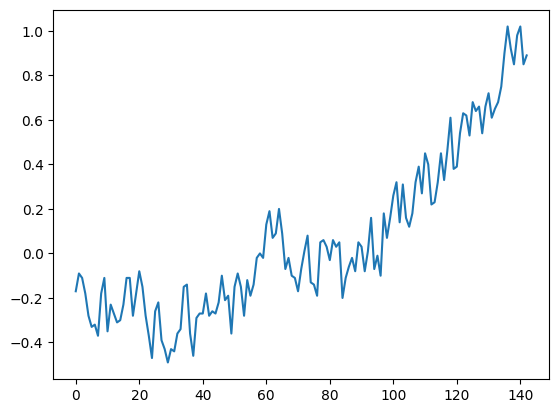

In [10]:
df_temp["j-d"].plot()

In [11]:
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
lowess = sm.nonparametric.lowess



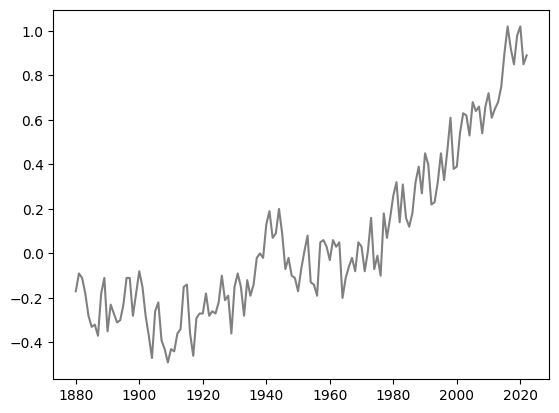

In [12]:

x = df_temp["year"]
y = df_temp["j-d"]
# get x and y values for LOWESS
x = df_temp["year"].values
y = df_temp["j-d"]
y_hat = lowess(y, x, frac=1/5)
#df_temp['lowess'] = y_hat[:,1]
plt.plot(x, y, color = "grey")

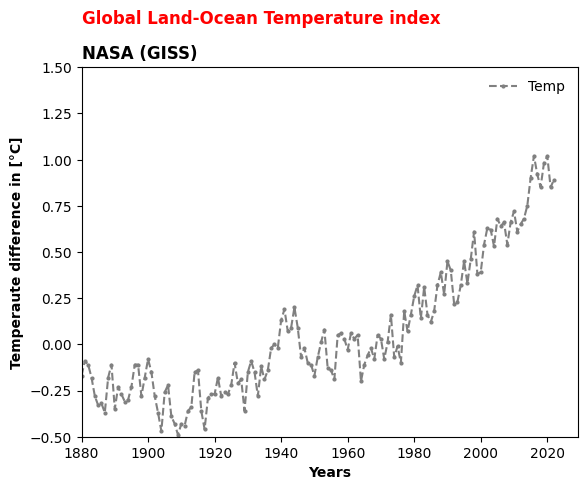

<Figure size 640x480 with 0 Axes>

In [13]:
plt.plot(x, y, color = "grey", linestyle='dashed', label='Temp',marker='o', markersize = 2)
plt.xlim(left = 1880 )
plt.ylim(-0.5, 1.5)
plt.suptitle("Global Land-Ocean Temperature index", color = "r", fontsize = "large",  fontweight = "bold", ha="left", x = 0.125, y = 1)
plt.title('NASA (GISS)',loc = "left", fontweight = "bold")
plt.xlabel('Years' , fontweight = "bold")
plt.ylabel('Temperaute difference in [\u00B0C]',fontweight = "bold")
plt.legend(loc='upper right', frameon=False)
plt.show()
plt.savefig('line_plot.png', dpi=600, bbox_inches='tight')



In [14]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


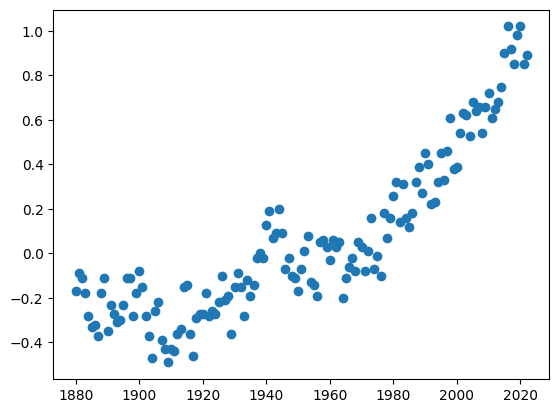

In [15]:
plt.scatter(x, y)

In [16]:
df1

,year,t_diff
0,1880,-0.17
1,1881,-0.09
2,1882,-0.11
3,1883,-0.18
4,1884,-0.28
...,...,...
139,2019,0.98
140,2020,1.02
141,2021,0.85
142,2022,0.89


In [17]:
temp_wider = t_data[t_data.columns[0 : 13]]
temp_wider

,year,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec
0,1880,-0.18,-0.24,-0.09,-0.16,-0.10,-0.21,-0.18,-0.10,-0.15,-0.23,-0.22,-0.17
1,1881,-0.20,-0.14,0.03,0.05,0.06,-0.19,0.00,-0.04,-0.15,-0.22,-0.19,-0.07
2,1882,0.16,0.14,0.04,-0.16,-0.14,-0.22,-0.16,-0.08,-0.15,-0.23,-0.17,-0.36
3,1883,-0.29,-0.37,-0.12,-0.19,-0.18,-0.07,-0.07,-0.14,-0.22,-0.11,-0.24,-0.11
4,1884,-0.13,-0.09,-0.36,-0.40,-0.34,-0.35,-0.31,-0.28,-0.27,-0.25,-0.33,-0.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,2019,0.93,0.95,1.17,1.01,0.85,0.91,0.94,0.95,0.93,1.01,0.99,1.09
140,2020,1.17,1.24,1.17,1.13,1.02,0.92,0.90,0.88,0.99,0.89,1.11,0.81
141,2021,0.82,0.64,0.89,0.76,0.78,0.84,0.92,0.82,0.92,1.00,0.94,0.86
142,2022,0.91,0.89,1.05,0.84,0.84,0.92,0.93,0.95,0.90,0.97,0.73,0.80


### convert into longer format using the melt 
### its same as unpivot of excel function.

In [18]:
temp_wider.melt(id_vars= "year")

,year,variable,value
0,1880,jan,-0.18
1,1881,jan,-0.20
2,1882,jan,0.16
3,1883,jan,-0.29
4,1884,jan,-0.13
...,...,...,...
1723,2019,dec,1.09
1724,2020,dec,0.81
1725,2021,dec,0.86
1726,2022,dec,0.80


In [19]:
temp_longer = temp_wider.melt(id_vars = "year",var_name="month",value_name="value")
temp_longer

,year,month,value
0,1880,jan,-0.18
1,1881,jan,-0.20
2,1882,jan,0.16
3,1883,jan,-0.29
4,1884,jan,-0.13
...,...,...,...
1723,2019,dec,1.09
1724,2020,dec,0.81
1725,2021,dec,0.86
1726,2022,dec,0.80


In [20]:
temp_longer["year"].value_counts(ascending=True).tail()

1929    12
1930    12
1931    12
2022    12
2023    12
Name: year, dtype: int64

### here we drop the year 2023 because we have data only for three months.

In [21]:
temp_longer=temp_longer.drop(temp_longer[temp_longer["year"]==2023].index)
temp_longer["year"].value_counts(ascending=True).tail()

1928    12
1929    12
1930    12
1924    12
2022    12
Name: year, dtype: int64

## create multi index using year and month

In [22]:
temp_longer = temp_longer.set_index(["year","month"])
temp_longer.head(10)

,,value
year,month,
1880,jan,-0.18
1881,jan,-0.20
1882,jan,0.16
1883,jan,-0.29
1884,jan,-0.13
1885,jan,-0.59
1886,jan,-0.44
1887,jan,-0.72
1888,jan,-0.34


In [23]:
temp_longer=temp_longer.reset_index()
temp_longer.head()

,year,month,value
0,1880,jan,-0.18
1,1881,jan,-0.20
2,1882,jan,0.16
3,1883,jan,-0.29
4,1884,jan,-0.13


### now we start the data analysis 

In [24]:
temp_longer["value"].min()

-0.82

In [25]:
temp_longer["value"].max()

1.37

#### lets check the data for the 1880

In [26]:
hc_1880=temp_longer[temp_longer["year"]==1880]
r=hc_1880["value"]+1
theta=np.linspace(0,2*np.pi,12)

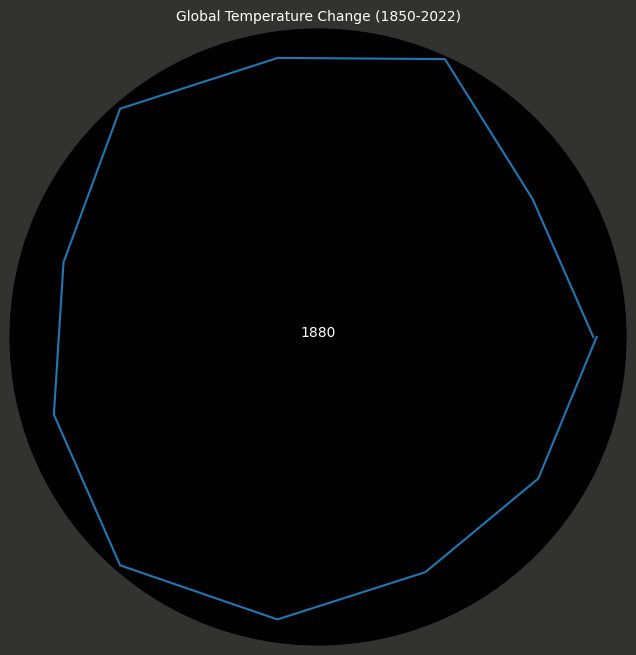

In [27]:
fig=plt.figure(figsize=(8,8))
ax1=plt.subplot(111,projection="polar")
ax1.plot(theta,r)
ax1.set_xticklabels([]) #  remove all x labels
ax1.set_yticklabels([]) # remve all y labels
ax1.set_xticks([]) #remove all x ticks
ax1.set_yticks([]) #remove all y ticks
fig.set_facecolor("#323331") #figure background "black"
ax1.set_facecolor("#000100") # inside the circle
ax1.set_title("Global Temperature Change (1850-2022)",color="white",fontsize=10, ha= "center")
ax1.text(0,0,"1880",color="white",size=10,ha="center")
plt.show()

### now lets add all the year data

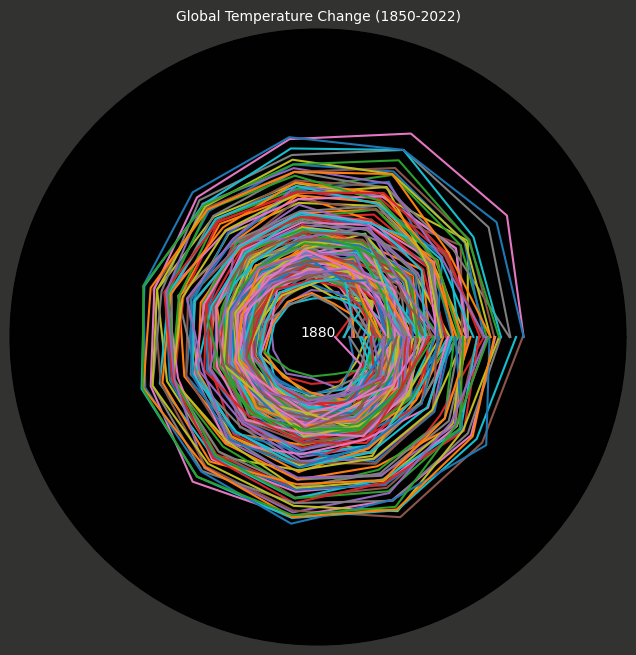

In [28]:
fig=plt.figure(figsize=(8,8))
ax1=plt.subplot(111,projection="polar")
ax1.set_xticklabels([]) #  remove all x labels
ax1.set_yticklabels([]) # remve all y labels
ax1.set_xticks([]) #remove all x ticks
ax1.set_yticks([]) #remove all y ticks
fig.set_facecolor("#323331") #figure background "black"
ax1.set_facecolor("#000100") # inside the circle
ax1.set_title("Global Temperature Change (1850-2022)",color="white",fontsize=10, ha= "center")
ax1.text(0,0,"1880",color="white",size=10,ha="center")
ax1.set_ylim(0, 3.25)

theta = np.linspace(0, 2*np.pi, 12)
years=temp_longer["year"].unique()

for year in years:
  r=temp_longer.loc[temp_longer["year"]==year,"value"]+1
  ax1.plot(theta,r)
plt.show()

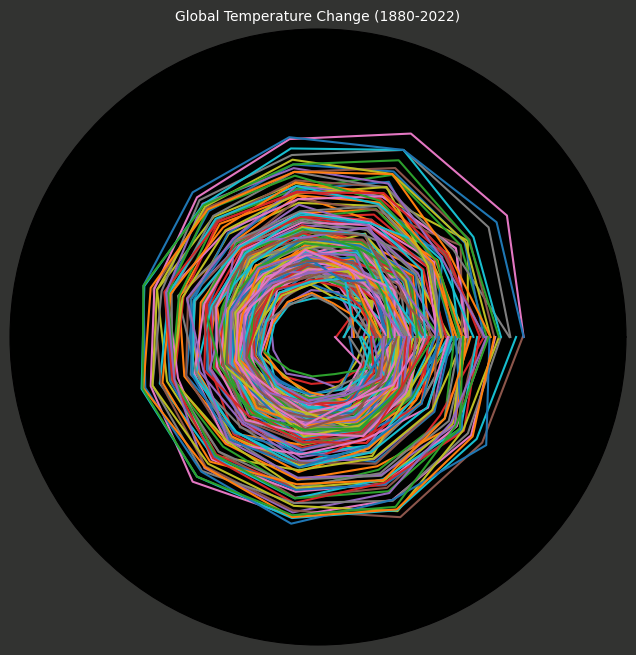

In [29]:
fig=plt.figure(figsize=(8,8))
ax1=plt.subplot(111,projection="polar")

ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.set_ylim(0,3.25)
fig.set_facecolor("#323331")
ax1.set_facecolor("#000100")
ax1.set_title("Global Temperature Change (1880-2022)",color="white",fontsize=10)
ax1.set_xticks([])
ax1.set_yticks([])

theta = np.linspace(0, 2*np.pi, 12)
years=temp_longer["year"].unique()

for year in years:
  r=temp_longer.loc[temp_longer["year"]==year,"value"]+1
  ax1.plot(theta,r)
plt.show()

## change the colour in plot spiral according to years temp data

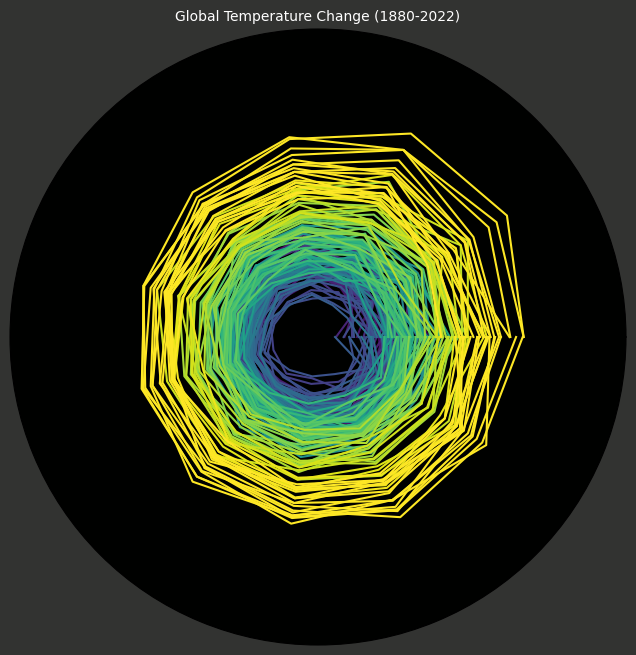

In [30]:
fig=plt.figure(figsize=(8,8))
ax1=plt.subplot(111,projection="polar")

ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.set_ylim(0,3.25)
fig.set_facecolor("#323331")
ax1.set_facecolor("#000100")
ax1.set_title("Global Temperature Change (1880-2022)",color="white",fontsize=10)
ax1.set_xticks([])
ax1.set_yticks([])

theta = np.linspace(0, 2*np.pi, 12)
years=temp_longer["year"].unique()

for index,year in enumerate(years):
  r=temp_longer.loc[temp_longer["year"]==year,"value"]+1
  ax1.plot(theta,r,c=plt.cm.viridis(index*2))
plt.show()

### we add the temp ring around the data to make the vizualisation more readable

In [31]:
full_circle_thetas=np.linspace(0,2*np.pi,1000)
blue_one_radii=[0.0+1.0]*1000
red_one_radii=[1.5+1.0]*1000
red_two_radii=[2.0+1.0]*1000

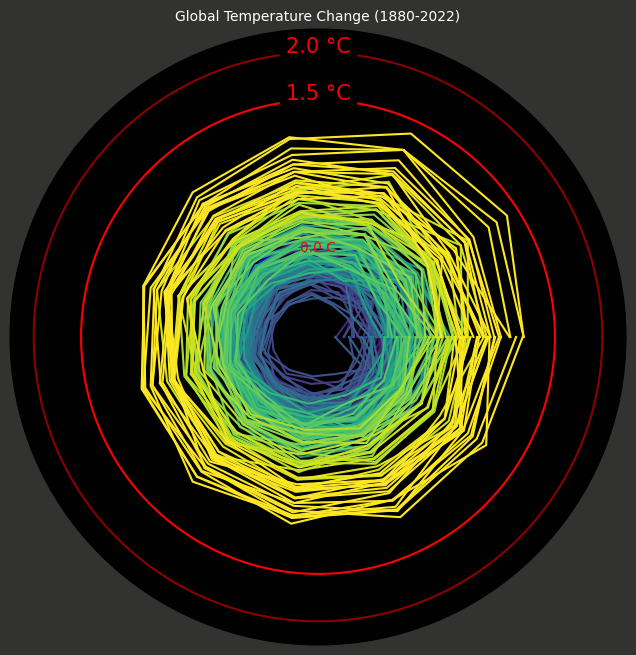

In [33]:
fig=plt.figure(figsize=(8,8))
ax1=plt.subplot(111,projection="polar")

ax1.plot(full_circle_thetas, blue_one_radii, c = "blue")
ax1.plot(full_circle_thetas, red_one_radii, c = "red")
ax1.plot(full_circle_thetas, red_two_radii, c = "darkred")

ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.set_ylim(0,3.25)
fig.set_facecolor("#323331")
ax1.set_facecolor("#000100")
ax1.set_title("Global Temperature Change (1880-2022)",color="white",fontsize=10)
ax1.set_xticks([])
ax1.set_yticks([])

#add temp in red rings
ax1.text(np.pi/2, 0.90, "0.0 C", color="red", ha='center')
ax1.text(np.pi/2, 2.50, "1.5 \u00B0C", color="red", ha='center', fontsize= 15,bbox=dict(facecolor='#000100', edgecolor='#000100'))
ax1.text(np.pi/2, 3.00, "2.0 \u00B0C", color="red", ha='center', fontsize= 15,bbox=dict(facecolor='#000100', edgecolor='#000100'))

theta = np.linspace(0, 2*np.pi, 12)
years=temp_longer["year"].unique()

for index,year in enumerate(years):
  r=temp_longer.loc[temp_longer["year"]==year,"value"]+1
  ax1.plot(theta,r,c=plt.cm.viridis(index*2))
plt.show()

### Let's add the month label to the temp points around the ring

In [34]:
months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

In [35]:
months_angles= np.linspace((np.pi/2)+(2*np.pi),np.pi/2,13)
for i,month in enumerate(months):
  ax1.text(months_angles[i],3.4,month,color="white",fontsize=15,ha="center")


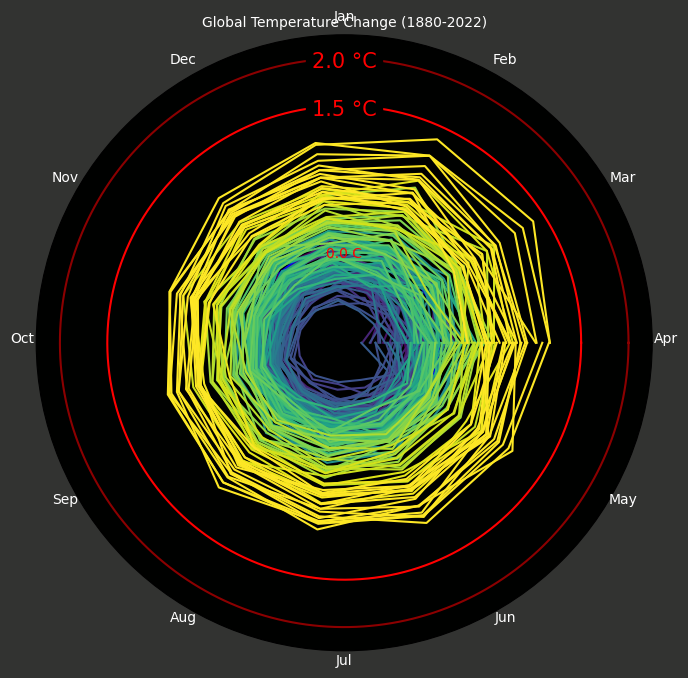

In [42]:
months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig=plt.figure(figsize=(8,8))
ax1=plt.subplot(111,projection="polar")

ax1.plot(full_circle_thetas, blue_one_radii, c = "blue")
ax1.plot(full_circle_thetas, red_one_radii, c = "red")
ax1.plot(full_circle_thetas, red_two_radii, c = "darkred")

ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.set_ylim(0,3.25)
fig.set_facecolor("#323331")
ax1.set_facecolor("#000100")
ax1.set_title("Global Temperature Change (1880-2022)",color="white",fontsize=10)
ax1.set_xticks([])
ax1.set_yticks([])

#add temp in red rings
ax1.text(np.pi/2, 0.90, "0.0 C", color="red", ha='center')
ax1.text(np.pi/2, 2.40, "1.5 \u00B0C", color="red", ha='center', fontsize= 15,bbox=dict(facecolor='#000100', edgecolor='#000100'))
ax1.text(np.pi/2, 2.90, "2.0 \u00B0C", color="red", ha='center', fontsize= 15,bbox=dict(facecolor='#000100', edgecolor='#000100'))

theta = np.linspace(0, 2*np.pi, 12)
years=temp_longer["year"].unique()

## add months to the ring

months_angles= np.linspace((np.pi/2)+(2*np.pi),np.pi/2,13)
for i,month in enumerate(months):
  ax1.text(months_angles[i],3.4,month,color="white",fontsize=10,ha="center")

for index,year in enumerate(years):
  r=temp_longer.loc[temp_longer["year"]==year,"value"]+1
  ax1.plot(theta,r,c=plt.cm.viridis(index*2))
plt.show()